In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

In [ ]:
data = '/content/drive/My Drive/CT-KIDNEY-DATASET/'

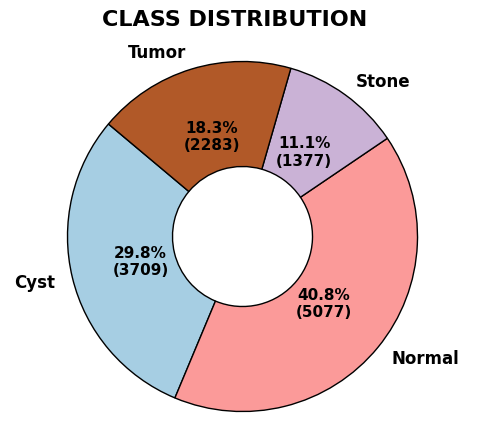

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
image_counts = {}
for folder_name in os.listdir(data):
    folder_path = os.path.join(data, folder_name)
    if os.path.isdir(folder_path):
        num_images = len([file for file in os.listdir(folder_path) if file.lower().endswith(('jpg', 'jpeg', 'png', 'bmp', 'gif'))])
        image_counts[folder_name] = num_images

image_counts = dict(sorted(image_counts.items()))
colors = plt.cm.Paired(np.linspace(0, 1, len(image_counts)))

def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{pct:.1f}%\n({absolute})"

plt.figure(figsize=(6,5), facecolor='white')
wedges, texts, autotexts = plt.pie(
    image_counts.values(), labels=image_counts.keys(), colors=colors,
    autopct=lambda pct: func(pct, list(image_counts.values())),
    startangle=140, wedgeprops=dict(edgecolor="black", linewidth=1)
)

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

plt.setp(wedges, width=0.6) 
plt.axis('equal')
plt.suptitle('CLASS DISTRIBUTION', y=0.95, fontsize=16, fontweight='bold')
plt.show()


In [ ]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 845.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 99.0 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
import tensorflow as tf
train = tf.keras.preprocessing.image_dataset_from_directory(
    data,
    seed=123,
    shuffle=True,
    image_size=(224,224),
    validation_split = 0.3,
    subset = 'training'
)
validation = tf.keras.preprocessing.image_dataset_from_directory(
    data,
    seed=123,
    shuffle=True,
    image_size=(224,224),
    validation_split = 0.3,
    subset = 'validation'
)

Found 12453 files belonging to 4 classes.
Using 8718 files for training.
Found 12453 files belonging to 4 classes.
Using 3735 files for validation.


In [ ]:
categories=train.class_names
print(categories)

['Cyst', 'Normal', 'Stone', 'Tumor']


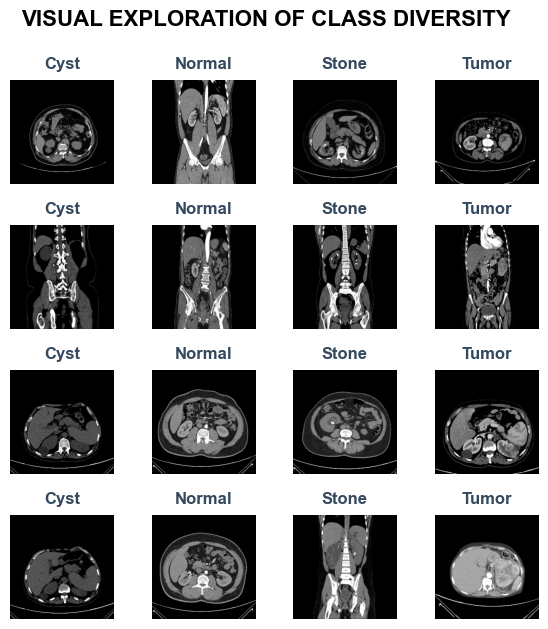

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("dark")
class_samples = [[] for _ in range(len(categories))]
required_samples = 4

for images, labels in train:
    for i, label in enumerate(labels):
        if len(class_samples[label.numpy()]) < required_samples:
            class_samples[label.numpy()].append(images[i])
    if all(len(samples) >= required_samples for samples in class_samples):
        break

fig, axes = plt.subplots(required_samples, len(categories), figsize=(7,7), dpi=100)
fig.suptitle("VISUAL EXPLORATION OF CLASS DIVERSITY", fontsize=16, fontweight='bold', color="BLACK")

edge_color = "#ff6b6b"  
linewidth = 3

for i in range(required_samples):
    for j in range(len(categories)):
        ax = axes[i, j] if required_samples > 1 else axes[j]
        ax.imshow(class_samples[j][i].numpy().astype("uint8"))
        ax.set_title(categories[j], fontsize=12, color="#34495e", pad=8, weight='bold')

        ax.spines['top'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_visible(True)
        ax.spines['right'].set_visible(True)

        for spine in ax.spines.values():
            spine.set_edgecolor(edge_color)
            spine.set_linewidth(linewidth)

        ax.axis("off")

plt.subplots_adjust(wspace=0.2, hspace=0.4)
plt.show()


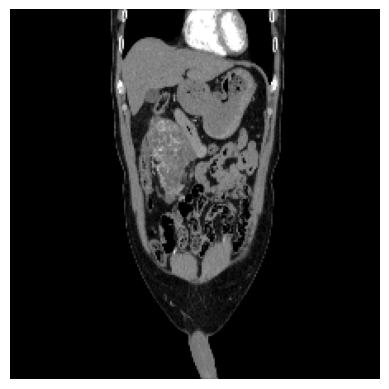

In [ ]:
import cv2

img = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img, (224, 224))

plt.imshow(img)
plt.axis('off')
plt.show()

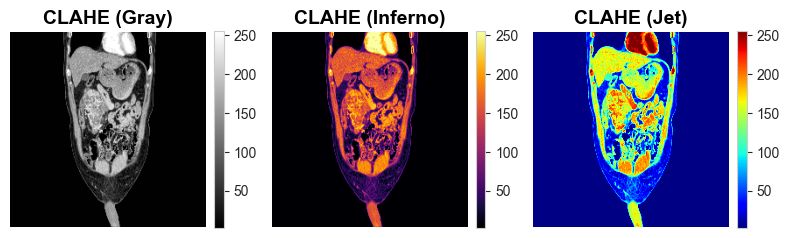

In [ ]:

import seaborn as sns
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(6,3))
clahe_img = clahe.apply(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))

sns.set_style("whitegrid")

colormaps = ['gray', 'inferno', 'jet']
titles = ['CLAHE (Gray)', 'CLAHE (Inferno)', 'CLAHE (Jet)']
fig, axes = plt.subplots(1, 3, figsize=(8,3))

for i, ax in enumerate(axes):
    im = ax.imshow(clahe_img, cmap=colormaps[i])
    ax.set_title(titles[i], fontsize=14, fontweight='bold', color='black')
    ax.axis('off')

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


In [ ]:
#pip install scikit-fuzzy

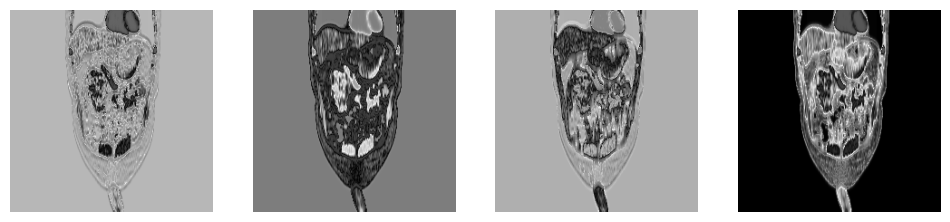

In [ ]:
import skfuzzy as fuzz
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
def multi_kernel_fuzzy_cmeans(img, n_clusters, kernel_size):
    kernels = [cv2.getGaussianKernel(kernel_size[i], -1) for i in range(len(kernel_size))]
    n_kernels = len(kernels)

    memberships = []
    for i in range(n_kernels):
        blurred_img = cv2.filter2D(img, -1, kernels[i])
        flat_img = blurred_img.flatten()

        cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
            flat_img[np.newaxis, :], n_clusters, 3, error=0.005, maxiter=1000)

        memberships.append(u)

    combined_membership = np.mean(memberships, axis=0)

    combined_membership = combined_membership.reshape((n_clusters, img.shape[0], img.shape[1]))

    return combined_membership

n_clusters = 4
kernel_size = [5, 9, 15]

membership = multi_kernel_fuzzy_cmeans(clahe_img, n_clusters, kernel_size)

plt.figure(figsize=(12, 4))
for i in range(n_clusters):
    plt.subplot(1, n_clusters, i+1)
    plt.imshow(membership[i], cmap='gray')
    plt.axis('off')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.applications import VGG16

def transformer_block(x, num_heads=8, ff_dim=256, dropout_rate=0.1):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=ff_dim)(x, x)
    attn_output = layers.Dropout(dropout_rate)(attn_output)
    x = layers.Add()([x, attn_output])
    x = layers.LayerNormalization()(x)

    ffn_output = layers.Dense(ff_dim, activation='gelu')(x)
    ffn_output = layers.Dense(x.shape[-1])(ffn_output)
    ffn_output = layers.Dropout(dropout_rate)(ffn_output)
    x = layers.Add()([x, ffn_output])
    x = layers.LayerNormalization()(x)
    return x

base_model = VGG16(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
base_model.trainable = False  

def residual_dilated_block(x, filters):
    res = layers.Conv2D(filters, (1, 1), padding='same')(x)  # Reduce channels to match `filters`

    x = layers.Conv2D(filters, (3, 3), dilation_rate=2, padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, (3, 3), dilation_rate=3, padding='same', activation='relu')(x)

    x = layers.Add()([x, res])  # Now both tensors have shape (7, 7, filters)
    return x


inputs = layers.Input(shape=(224, 224, 3))
x = layers.Rescaling(1.0 / 255)(inputs)
x = base_model(x)

x = residual_dilated_block(x, 256)
x = residual_dilated_block(x, 256)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256)(x)
x = layers.Reshape((1, 256))(x)  
x = transformer_block(x)

x = layers.Flatten()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(4, activation='softmax')(x)

model = Model(inputs, x)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    train,
    validation_data=validation,
    epochs=10
)

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_2 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vgg16 (Functional)        │ (None, 7, 7, 512)      │     14,714,688 │ rescaling_2[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 7, 7, 256)      │      1,179,904 │ vgg16[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 7, 7, 256)      │        590,080 │ conv2d_7[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 7, 7, 256)      │        131,328 │ vgg16[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_4 (Add)               │ (None, 7, 7, 256)      │              0 │ conv2d_8[0][0],        │
│                           │                        │                │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 7, 7, 256)      │        590,080 │ add_4[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_11 (Conv2D)        │ (None, 7, 7, 256)      │        590,080 │ conv2d_10[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 7, 7, 256)      │         65,792 │ add_4[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_5 (Add)               │ (None, 7, 7, 256)      │              0 │ conv2d_11[0][0],       │
│                           │                        │                │ conv2d_9[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 256)            │              0 │ add_5[0][0]            │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_11 (Dense)          │ (None, 256)            │         65,792 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_1 (Reshape)       │ (None, 1, 256)         │              0 │ dense_11[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_1    │ (None, 1, 256)         │      2,103,552 │ reshape_1[0][0],       │
│ (MultiHeadAttention)      │                        │                │ reshape_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 1, 256)         │              0 │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_6 (Add)               │ (None, 1, 256)         │              0 │ reshape_1[0][0],       │
│                      

 Total params: 20,207,268 (77.08 MB)

 Trainable params: 5,492,580 (20.95 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10


In [ ]:
import time
import psutil
from tensorflow.keras.callbacks import ModelCheckpoint
model_checkpoint = ModelCheckpoint(
    filepath='model_weights_epoch_{epoch:03d}_val_accuracy_{val_accuracy:.4f}.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

history = model.fit(
    train,
    validation_data=validation,
    epochs=10,callbacks=[model_checkpoint]
)
best_epoch = history.history['val_accuracy'].index(max(history.history['val_accuracy'])) + 1

model.load_weights(f'model_weights_epoch_{best_epoch:03d}_val_accuracy_{max(history.history["val_accuracy"]):.4f}.keras')

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 1812s 7s/step - accuracy: 0.6924 - loss: 0.7828 - val_accuracy: 0.8388 - val_loss: 0.4475
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 96s 352ms/step - accuracy: 0.8739 - loss: 0.3470 - val_accuracy: 0.9151 - val_loss: 0.2373
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 76s 280ms/step - accuracy: 0.9214 - loss: 0.2166 - val_accuracy: 0.9365 - val_loss: 0.1761
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 82s 280ms/step - accuracy: 0.9604 - loss: 0.1195 - val_accuracy: 0.9515 - val_loss: 0.1365
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 96s 352ms/step - accuracy: 0.9657 - loss: 0.0982 - val_accuracy: 0.9422 - val_loss: 0.1608
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 75s 273ms/step - accuracy: 0.9745 - loss: 0.0741 - val_accuracy: 0.9751 - val_loss: 0.0730
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 106s 388ms/step - accuracy: 0.9791 - loss: 0.0599 - val_accuracy: 0.9687 - val_loss: 0.0878
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 75s 274ms/step - accuracy: 0.9885 - loss: 0

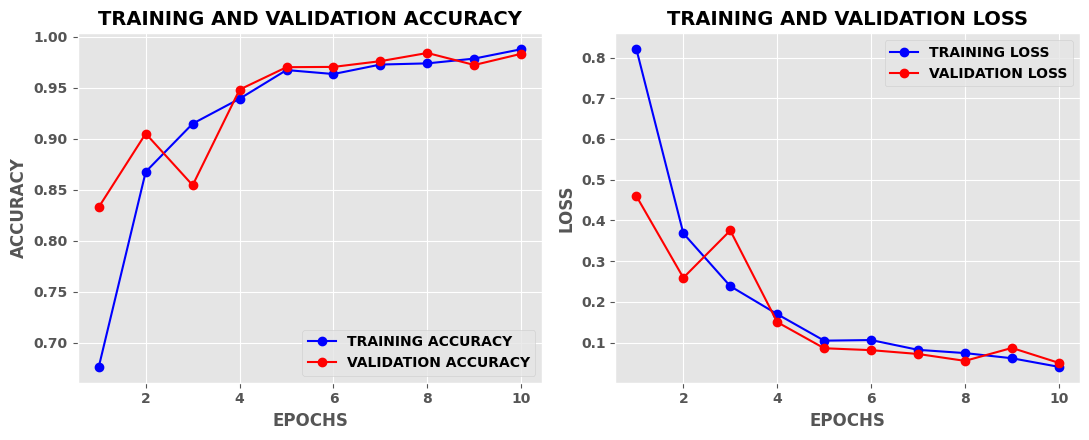

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.style.use('ggplot')
plt.figure(figsize=(11,4.5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='TRAINING ACCURACY')
plt.plot(epochs, val_acc, 'ro-', label='VALIDATION ACCURACY')
plt.title('TRAINING AND VALIDATION ACCURACY', fontsize=14, fontweight='bold')
plt.xlabel('EPOCHS', fontsize=12, fontweight='bold')
plt.ylabel('ACCURACY', fontsize=12, fontweight='bold')
plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')
plt.legend(fontsize=10, loc='best', prop={'weight': 'bold'})

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='TRAINING LOSS')
plt.plot(epochs, val_loss, 'ro-', label='VALIDATION LOSS')
plt.title('TRAINING AND VALIDATION LOSS', fontsize=14, fontweight='bold')
plt.xlabel('EPOCHS', fontsize=12, fontweight='bold')
plt.ylabel('LOSS', fontsize=12, fontweight='bold')
plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')
plt.legend(fontsize=10, loc='best', prop={'weight': 'bold'})

plt.tight_layout()
plt.show()


In [ ]:
model.save("kidney1.h5")

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, precision_recall_fscore_support
num_classes = 4

validation_images = []
validation_labels = []
for images, labels in validation:
    validation_images.append(images.numpy())
    validation_labels.append(labels.numpy())

validation_images = np.concatenate(validation_images)
validation_labels = np.concatenate(validation_labels)

predictions = model.predict(validation_images)
predicted_labels = np.argmax(predictions, axis=1)

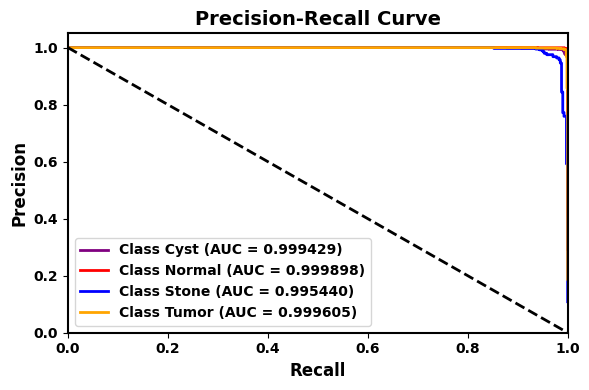

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

y_true_bin = label_binarize(validation_labels, classes=np.arange(num_classes))

precision = dict()
recall = dict()
pr_auc = dict()

for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_true_bin[:, i], predictions[:, i]
    )
    pr_auc[i] = average_precision_score(
        y_true_bin[:, i], predictions[:, i]
    )

colors = ['purple', 'red', 'blue', 'orange']

plt.figure(figsize=(6,4))

for i in range(num_classes):
    plt.plot(
        recall[i],
        precision[i],
        color=colors[i],
        lw=2,
        label=f'Class {categories[i]} (AUC = {pr_auc[i]:f})'
    )

plt.plot([0, 1], [1, 0], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('Recall', fontweight='bold', fontsize=12)
plt.ylabel('Precision', fontweight='bold', fontsize=12)
plt.title('Precision-Recall Curve', fontweight='bold', fontsize=14)

legend = plt.legend(loc="lower left", prop={'weight': 'bold', 'size': 10})

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.grid(False)

plt.tight_layout()
plt.show()

117/117 ━━━━━━━━━━━━━━━━━━━━ 21s 178ms/step

=== Macro-Averaged Performance Metrics ===
Accuracy: 0.9839
Precision (Macro): 0.9834
Recall (Macro): 0.9731
F1-score (Macro): 0.9780
False Negative Rate (Macro): 0.0269
False Positive Rate (Macro): 0.0058
Negative Predictive Value (Macro): 0.9949
Specificity (Macro): 0.9942
Balanced Accuracy (Macro): 0.9836
Matthews Correlation Coefficient (MCC): 0.9770
Cohen’s Kappa Score: 0.9769
Jaccard Score (Macro IoU): 0.9574


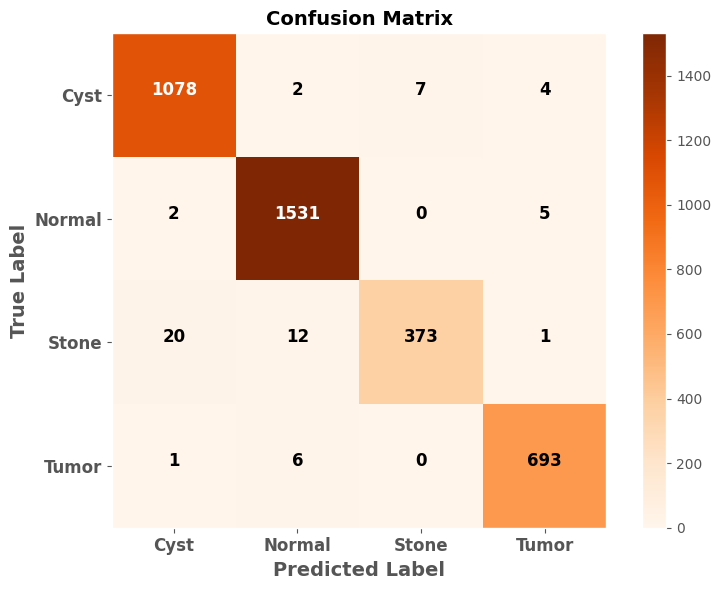

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_recall_fscore_support, matthews_corrcoef, cohen_kappa_score, jaccard_score
)

num_classes = 4

validation_images = []
validation_labels = []
for images, labels in validation:
    validation_images.append(images.numpy())
    validation_labels.append(labels.numpy())

validation_images = np.concatenate(validation_images)
validation_labels = np.concatenate(validation_labels)

predictions = model.predict(validation_images)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(validation_labels, predicted_labels)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(validation_labels, predicted_labels, average='macro')

FNR, FPR, NPV, Specificity = [], [], [], []
for i in range(num_classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    fnr = FN / (FN + TP) if (FN + TP) > 0 else 0  
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0  
    npv = TN / (TN + FN) if (TN + FN) > 0 else 0  
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0  

    FNR.append(fnr)
    FPR.append(fpr)
    NPV.append(npv)
    Specificity.append(specificity)

fnr_macro = np.mean(FNR)
fpr_macro = np.mean(FPR)
npv_macro = np.mean(NPV)
specificity_macro = np.mean(Specificity)
balanced_accuracy_macro = (specificity_macro + recall_macro) / 2
mcc = matthews_corrcoef(validation_labels, predicted_labels)
cohen_kappa = cohen_kappa_score(validation_labels, predicted_labels)
jaccard_macro = jaccard_score(validation_labels, predicted_labels, average='macro')

print("\n=== Macro-Averaged Performance Metrics ===")
print(f"Accuracy: {accuracy_score(validation_labels, predicted_labels):.4f}")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"F1-score (Macro): {f1_macro:.4f}")
print(f"False Negative Rate (Macro): {fnr_macro:.4f}")
print(f"False Positive Rate (Macro): {fpr_macro:.4f}")
print(f"Negative Predictive Value (Macro): {npv_macro:.4f}")
print(f"Specificity (Macro): {specificity_macro:.4f}")
print(f"Balanced Accuracy (Macro): {balanced_accuracy_macro:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
print(f"Cohen’s Kappa Score: {cohen_kappa:.4f}")
print(f"Jaccard Score (Macro IoU): {jaccard_macro:.4f}")

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Oranges)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.colorbar()
tick_marks = np.arange(len(categories))
plt.xticks(tick_marks, categories, rotation=0, fontsize=12, fontweight='bold')
plt.yticks(tick_marks, categories, fontsize=12, fontweight='bold')

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=12, fontweight='bold')

plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()


Cyst: Precision=0.98, Recall=0.99, F1 Score=0.98
Normal: Precision=0.99, Recall=1.00, F1 Score=0.99
Stone: Precision=0.98, Recall=0.92, F1 Score=0.95
Tumor: Precision=0.99, Recall=0.99, F1 Score=0.99
Specificity : [np.float64(99.13010590015129), np.float64(99.08966772872098), np.float64(99.78972664463804), np.float64(99.67051070840198)]
Sensitivity : [np.float64(98.80843263061412), np.float64(99.54486345903771), np.float64(91.87192118226602), np.float64(99.0)]


<Figure size 1000x600 with 0 Axes>

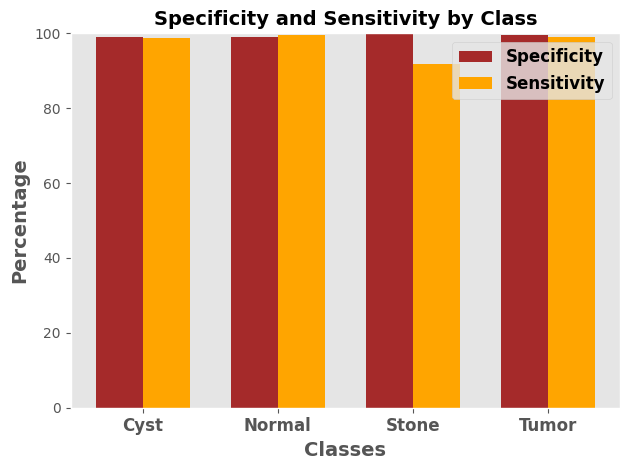

In [ ]:
precision, recall, f1, _ = precision_recall_fscore_support(validation_labels, predicted_labels, average=None)
for i, category in enumerate(categories):
    print(f'{category}: Precision={precision[i]:.2f}, Recall={recall[i]:.2f}, F1 Score={f1[i]:.2f}')
specificity = []
sensitivity = []
for i in range(num_classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)
    specificity.append(TN / (TN + FP) * 100)
    sensitivity.append(TP / (TP + FN) * 100)

print('Specificity :', specificity)
print('Sensitivity :', sensitivity)

labels = [categories[i] for i in range(num_classes)]
values_spec = specificity
values_sens = sensitivity

plt.figure(figsize=(10, 6))
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
bar1 = ax.bar(x - width/2, values_spec, width, label='Specificity', color="brown")
bar2 = ax.bar(x + width/2, values_sens, width, label='Sensitivity', color="orange")

ax.set_xlabel('Classes', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage', fontsize=14, fontweight='bold')
ax.set_title('Specificity and Sensitivity by Class', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.legend(prop={'size': 12, 'weight': 'bold'})
plt.ylim(0, 100)
plt.grid(False)
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

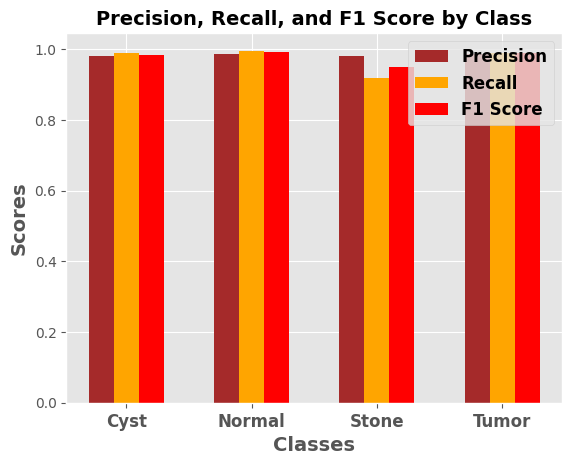

In [ ]:
plt.figure(figsize=(12, 8))
x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots()
bar1 = ax.bar(x - width, precision, width, label='Precision', color="brown")
bar2 = ax.bar(x, recall, width, label='Recall', color="orange")
bar3 = ax.bar(x + width, f1, width, label='F1 Score', color="red")

ax.set_xlabel('Classes', fontsize=14, fontweight='bold')
ax.set_ylabel('Scores', fontsize=14, fontweight='bold')
ax.set_title('Precision, Recall, and F1 Score by Class', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax.legend(prop={'size': 12, 'weight': 'bold'})

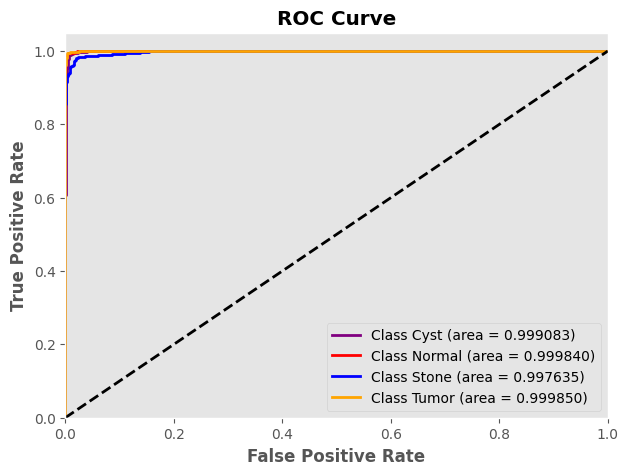

In [ ]:
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve((validation_labels == i).astype(int), predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = ['purple', 'red', 'blue', 'orange']
plt.figure(figsize=(7,5))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2, label='Class {0} (area = {1:2f})'.format(categories[i], roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate',fontweight='bold')
plt.ylabel('True Positive Rate',fontweight='bold')
plt.title('ROC Curve',fontweight='bold')
plt.legend(loc="lower right")
plt.grid(False)
plt.show()


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from lime import lime_image
from skimage.segmentation import mark_boundaries
img1 = "Input.jpg"
img = image.load_img(img1, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0
explainer = lime_image.LimeImageExplainer()

In [ ]:
def predict(images):
    preds = model.predict(images)
    return preds

In [ ]:
explanation = explainer.explain_instance(img_array[0].astype('double'),
                                         predict,
                                         top_labels=4,
                                         hide_color=0,
                                         num_samples=1000)

In [ ]:
label = np.argmax(model.predict(img_array))
temp, mask = explanation.get_image_and_mask(label,
                                            positive_only=False,
                                            num_features=10,
                                            hide_rest=False)

fig, ax = plt.subplots(1, 2)
ax[0].imshow(img)
ax[0].set_title('Original Image')
ax[1].imshow(mark_boundaries(temp / 255.0, mask))
ax[1].set_title('LIME Explanation')
plt.grid(False)
plt.show()

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
validation_iterator = iter(validation)
sample_batch = next(validation_iterator)
sample_image = sample_batch[0][0]
sample_image = sample_image.numpy()
sample_image = sample_image.reshape((224, 224, 3))
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(sample_image, model.predict, top_labels=5, hide_color=0, num_samples=1000)
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=True)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.show()